# Part 3: MACHINE LEARNING MODELING



## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor
)
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

import joblib

RANDOM_STATE = 42


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Cleaned Data

Loads the GGE-converted outputs saved at the end of Part 1:
 `df_gge_fuel` (long/tidy, one row per agency + mode + fuel type, with reported amounts only).

In [4]:
import pandas as pd
path =  r'/content/drive/MyDrive/axsos-dataset/cleaned_dataset.csv.xlsx'
model_df = pd.read_excel(path)
print("Dataset shape:", model_df.shape)
model_df.head()



Dataset shape: (2942, 34)


,agency,city,state,organization_type,report_year,uace_code,primary_uza_population,agency_voms,mode_name,typeofservicecd,...,hydrogen_mpkg_,other_fuel_mpg,electric_propulsion_mi_kwh,electric_battery_mi_kwh,Total_GGE,Fuel_Column,Amount_Original,Fuel Type,GGE_Factor,GGE
0,"King County, dba: King County Metro",Seattle,WA,"City, County or Local Government Unit or Depar...",2023,80389,3544011,2270,Demand Response,PT,...,NaN,NaN,NaN,NaN,1177253.92,diesel_gal,17880,Diesel,1.12,20025.60
1,"King County, dba: King County Metro",Seattle,WA,"City, County or Local Government Unit or Depar...",2023,80389,3544011,2270,Bus,PT,...,NaN,NaN,NaN,NaN,175000.20,diesel_gal,43135,Diesel,1.12,48311.20
2,"King County, dba: King County Metro",Seattle,WA,"City, County or Local Government Unit or Depar...",2023,80389,3544011,2270,Bus,DO,...,NaN,NaN,NaN,0.31,8335655.27,diesel_gal,7006268,Diesel,1.12,7847020.16
3,"King County, dba: King County Metro",Seattle,WA,"City, County or Local Government Unit or Depar...",2023,80389,3544011,2270,Ferryboat,DO,...,NaN,NaN,NaN,NaN,225124.97,diesel_gal,5591,Diesel,1.12,6261.92
4,Spokane Transit Authority,Spokane,WA,Independent Public Agency or Authority of Tran...,2023,83764,447279,300,Demand Response,DO,...,NaN,NaN,NaN,NaN,156466.00,diesel_gal,30325,Diesel,1.12,33964.00


In [5]:
#  BASIC VALIDATION


print("Number of rows:", len(model_df))
print("Number of columns:", model_df.shape[1])

print("\nAvailable columns:")
print(model_df.columns.tolist())

Number of rows: 2942
Number of columns: 34

Available columns:
['agency', 'city', 'state', 'organization_type', 'report_year', 'uace_code', 'primary_uza_population', 'agency_voms', 'mode_name', 'typeofservicecd', 'mode_voms', 'diesel', 'gasoline', 'liquefied_petroleum_gas', 'compressed_natural_gas', 'hydrogen', 'other_fuel', 'electric_propulsion', 'electric_battery', 'diesel_mpg', 'gasoline_mpg', 'liquefied_petroleum_gas_mpg', 'compressed_natural_gas_mpg', 'compressed_natural_gas_mpg_1', 'hydrogen_mpkg_', 'other_fuel_mpg', 'electric_propulsion_mi_kwh', 'electric_battery_mi_kwh', 'Total_GGE', 'Fuel_Column', 'Amount_Original', 'Fuel Type', 'GGE_Factor', 'GGE']


## DEFINE SAFE FEATURES


In [6]:
numeric_features = [
    "primary_uza_population",
    "agency_voms",
    "mode_voms"
]

categorical_features = [
    "state",
    "organization_type",
    "mode_name",
    "typeofservicecd",
    "Fuel Type"
]

features = numeric_features + categorical_features

original_target = "Amount_Original"
gge_target = "GGE"

required_columns = (
    features
    + ["agency"]
    + [original_target, gge_target]
)

missing_columns = [
    col for col in required_columns
    if col not in model_df.columns
]

if missing_columns:
    raise ValueError(
        f"These required columns are missing: {missing_columns}"
    )

df_ml = model_df[required_columns].copy()

print("Modeling dataset shape:", df_ml.shape)

df_ml.head()

Modeling dataset shape: (2942, 11)


,primary_uza_population,agency_voms,mode_voms,state,organization_type,mode_name,typeofservicecd,Fuel Type,agency,Amount_Original,GGE
0,3544011,2270,317.0,WA,"City, County or Local Government Unit or Depar...",Demand Response,PT,Diesel,"King County, dba: King County Metro",17880,20025.60
1,3544011,2270,58.0,WA,"City, County or Local Government Unit or Depar...",Bus,PT,Diesel,"King County, dba: King County Metro",43135,48311.20
2,3544011,2270,715.0,WA,"City, County or Local Government Unit or Depar...",Bus,DO,Diesel,"King County, dba: King County Metro",7006268,7847020.16
3,3544011,2270,2.0,WA,"City, County or Local Government Unit or Depar...",Ferryboat,DO,Diesel,"King County, dba: King County Metro",5591,6261.92
4,447279,300,55.0,WA,Independent Public Agency or Authority of Tran...,Demand Response,DO,Diesel,Spokane Transit Authority,30325,33964.00


## Clean the Targets

In [7]:
#  TARGET CLEANING


df_ml[original_target] = pd.to_numeric(
    df_ml[original_target],
    errors="coerce"
)

df_ml[gge_target] = pd.to_numeric(
    df_ml[gge_target],
    errors="coerce"
)

print("Missing Amount_Original:",
      df_ml[original_target].isna().sum())

print("Missing GGE:",
      df_ml[gge_target].isna().sum())

print("Negative Amount_Original:",
      (df_ml[original_target] < 0).sum())

print("Negative GGE:",
      (df_ml[gge_target] < 0).sum())

Missing Amount_Original: 0
Missing GGE: 0
Negative Amount_Original: 0
Negative GGE: 0


In [8]:
# ============================================================
# TARGET VALIDATION
# No rows are removed or modified in the modeling stage.
# ============================================================

df_ml[original_target] = pd.to_numeric(
    df_ml[original_target],
    errors="coerce"
)

df_ml[gge_target] = pd.to_numeric(
    df_ml[gge_target],
    errors="coerce"
)

print("Missing Amount_Original:",
      df_ml[original_target].isna().sum())

print("Missing GGE:",
      df_ml[gge_target].isna().sum())

print("Negative Amount_Original:",
      (df_ml[original_target] < 0).sum())

print("Negative GGE:",
      (df_ml[gge_target] < 0).sum())

print("Modeling dataset shape:", df_ml.shape)

Missing Amount_Original: 0
Missing GGE: 0
Negative Amount_Original: 0
Negative GGE: 0
Modeling dataset shape: (2942, 11)


## Check Target Distribution

In [9]:
#  TARGET DISTRIBUTION


print("Original Target Statistics")
display(df_ml[original_target].describe())

print("\nGGE Target Statistics")
display(df_ml[gge_target].describe())

Original Target Statistics


,Amount_Original
count,2.942000e+03
mean,2.339077e+06
std,3.502915e+07
min,0.000000e+00
25%,0.000000e+00
50%,1.970900e+04
75%,1.519612e+05
max,1.546270e+09



GGE Target Statistics


,GGE
count,2.942000e+03
mean,3.345311e+05
std,1.671578e+06
min,0.000000e+00
25%,0.000000e+00
50%,1.132800e+04
75%,1.138048e+05
max,4.638809e+07


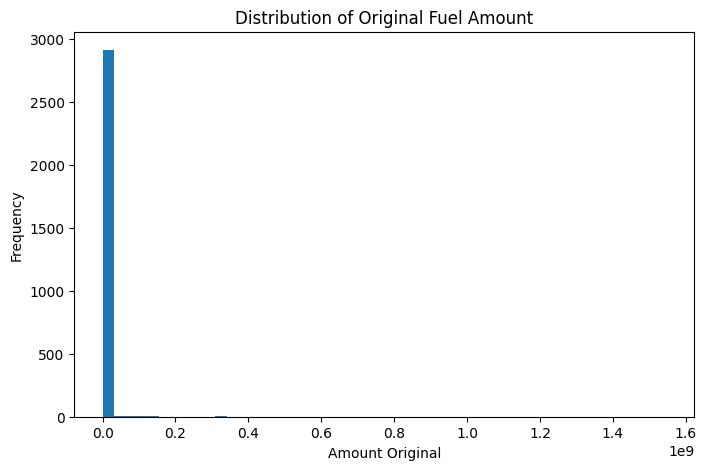

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df_ml[original_target], bins=50)
plt.xlabel("Amount Original")
plt.ylabel("Frequency")
plt.title("Distribution of Original Fuel Amount")
plt.show()

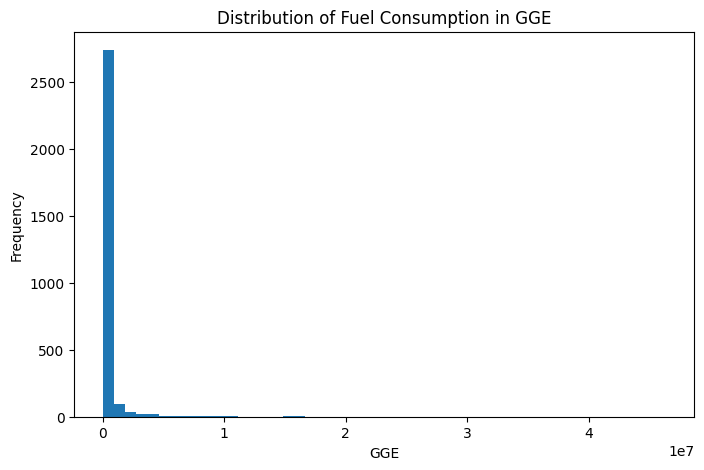

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df_ml[gge_target], bins=50)
plt.xlabel("GGE")
plt.ylabel("Frequency")
plt.title("Distribution of Fuel Consumption in GGE")
plt.show()

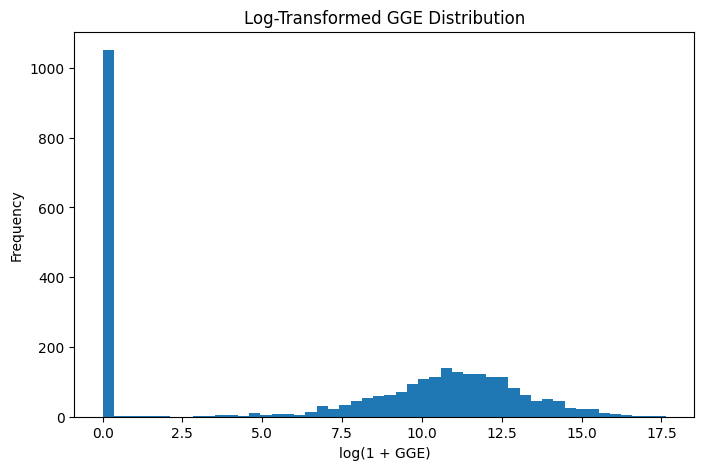

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(df_ml[gge_target]),
    bins=50
)

plt.xlabel("log(1 + GGE)")
plt.ylabel("Frequency")
plt.title("Log-Transformed GGE Distribution")
plt.show()

## Zero-Value Analysis
Zero target values were inspected to understand the target distribution. No observations were removed or modified during modeling.

In [29]:
# ============================================================
# CHECK ZERO TARGET VALUES
# ============================================================

zero_count = (df_ml["GGE"] == 0).sum()
positive_count = (df_ml["GGE"] > 0).sum()

print("Zero GGE rows:", zero_count)
print("Positive GGE rows:", positive_count)
print("Zero percentage:", zero_count / len(df_ml) * 100)

Zero GGE rows: 1051
Positive GGE rows: 1891
Zero percentage: 35.72399728076139


In [30]:
zero_by_fuel = (
    df_ml
    .assign(Is_Zero=df_ml["GGE"] == 0)
    .groupby("Fuel Type")
    .agg(
        Total_Rows=("GGE", "size"),
        Zero_Rows=("Is_Zero", "sum")
    )
)

zero_by_fuel["Zero_Percentage"] = (
    zero_by_fuel["Zero_Rows"]
    / zero_by_fuel["Total_Rows"]
    * 100
)

zero_by_fuel.sort_values(
    "Zero_Percentage",
    ascending=False
)

,Total_Rows,Zero_Rows,Zero_Percentage
Fuel Type,,,
Electric Battery,1237,1051,84.963622
Biodiesel,73,0,0.000000
CNG,209,0,0.000000
Diesel,558,0,0.000000
Electric Propulsion,90,0,0.000000
Gasoline,707,0,0.000000
Hydrogen,9,0,0.000000
LPG,54,0,0.000000
Other Fuel,5,0,0.000000


In [13]:
# ============================================================
#  GROUP-BASED TRAIN / TEST SPLIT
# ============================================================

X = df_ml[features].copy()

y_original = df_ml[original_target].copy()
y_gge = df_ml[gge_target].copy()

groups = df_ml["agency"].copy()

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    group_split.split(
        X,
        y_gge,
        groups=groups
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_original_train = y_original.iloc[train_idx].copy()
y_original_test = y_original.iloc[test_idx].copy()

y_gge_train = y_gge.iloc[train_idx].copy()
y_gge_test = y_gge.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("Training agencies:", groups_train.nunique())
print("Testing agencies:", groups_test.nunique())

Training rows: 2348
Testing rows: 594
Training agencies: 416
Testing agencies: 104


In [14]:
train_agencies = set(groups_train.unique())
test_agencies = set(groups_test.unique())

overlap = train_agencies.intersection(test_agencies)

print("Agency overlap:", len(overlap))

assert len(overlap) == 0, \
    "Data leakage detected: an agency exists in both train and test!"

print("No agency leakage between train and test.")

Agency overlap: 0
No agency leakage between train and test.


In [15]:
# ============================================================
#  PREPROCESSING
# ============================================================

def create_tree_preprocessor():

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_features
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    return preprocessor

In [16]:
def create_linear_preprocessor():

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_features
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    return preprocessor

In [17]:
# ============================================================
# 8. REGRESSION EVALUATION FUNCTION
# ============================================================

def evaluate_regression(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    median_ae = median_absolute_error(
        y_true,
        y_pred
    )

    mean_target = np.mean(y_true)

    if mean_target != 0:
        normalized_rmse = rmse / mean_target
    else:
        normalized_rmse = np.nan

    return {
        "Model": model_name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Median_AE": median_ae,
        "Normalized_RMSE": normalized_rmse
    }

## RANDOM FOREST BEFORE UNIT STANDARDIZATION

In [18]:
# ============================================================
# 9. RANDOM FOREST - ORIGINAL UNITS
# ============================================================

rf_original = Pipeline(
    steps=[
        (
            "preprocessing",
            create_tree_preprocessor()
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=400,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=2,
                max_features=0.8,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [19]:
rf_original.fit(
    X_train,
    y_original_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['primary_uza_population',
                                                   'agency_voms',
                                                   'mode_voms']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['state', 'organization_type',
                                                   'mode_name',
                                                   'typeofservicecd',
                                                   'Fuel Type'])])),
                ('model',
                 RandomForestRegressor(max_features=0.8, min_samples_leaf=2,
                                       n_estimators=400, n_jobs=-1,
                                       random_state=42))])

In [20]:
pred_original_rf = rf_original.predict(
    X_test
)

In [21]:
rf_original_results = evaluate_regression(
    model_name="Random Forest - Original Units",
    y_true=y_original_test,
    y_pred=pred_original_rf
)

pd.DataFrame(
    [rf_original_results]
)

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Random Forest - Original Units,0.458149,3.114767e+06,4.807898e+07,44999.189772,11.074493


## RANDOM FOREST AFTER GGE CONVERSION

In [22]:

rf_gge_baseline = Pipeline(
    steps=[
        (
            "preprocessing",
            create_tree_preprocessor()
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=400,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=2,
                max_features=0.8,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [23]:
rf_gge_baseline.fit(
    X_train,
    y_gge_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['primary_uza_population',
                                                   'agency_voms',
                                                   'mode_voms']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['state', 'organization_type',
                                                   'mode_name',
                                                   'typeofservicecd',
                                                   'Fuel Type'])])),
                ('model',
                 RandomForestRegressor(max_features=0.8, min_samples_leaf=2,
                                       n_estimators=400, n_jobs=-1,
                                       random_state=42))])

In [24]:
pred_gge_rf = rf_gge_baseline.predict(
    X_test
)

In [25]:
rf_gge_results = evaluate_regression(
    model_name="Random Forest - GGE",
    y_true=y_gge_test,
    y_pred=pred_gge_rf
)

pd.DataFrame(
    [rf_gge_results]
)

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Random Forest - GGE,0.543972,372231.336893,1.902214e+06,15171.692409,3.537877


## Compare Random Forest Before vs After Standardization

In [49]:
unit_comparison = pd.DataFrame(
    [
        rf_original_results,
        rf_gge_results
    ]
)

unit_comparison

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Random Forest - Original Units,0.458149,3.114767e+06,4.807898e+07,44999.189772,11.074493
1,Random Forest - GGE,0.543972,3.722313e+05,1.902214e+06,15171.692409,3.537877


In [26]:
# Target distribution
df_ml["GGE"].describe(percentiles=[
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

,GGE
count,2.942000e+03
mean,3.345311e+05
std,1.671578e+06
min,0.000000e+00
50%,1.132800e+04
75%,1.138048e+05
90%,4.967439e+05
95%,1.354521e+06
99%,5.976905e+06
max,4.638809e+07


In [27]:
print("Mean:", df_ml["GGE"].mean())
print("Median:", df_ml["GGE"].median())
print("Max:", df_ml["GGE"].max())

print(
    "Mean / Median ratio:",
    df_ml["GGE"].mean() / df_ml["GGE"].median()
)

Mean: 334531.0822671652
Median: 11328.0
Max: 46388088.0
Mean / Median ratio: 29.53134553912122


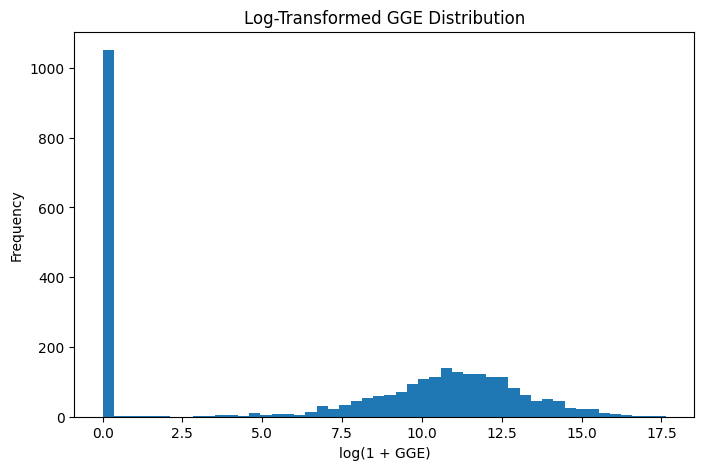

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(df_ml["GGE"]),
    bins=50
)

plt.xlabel("log(1 + GGE)")
plt.ylabel("Frequency")
plt.title("Log-Transformed GGE Distribution")

plt.show()

## FINAL MODELING USING GGE

### A. RANDOM FOREST - GGE WITH LOG-TRANSFORMED TARGET

In [31]:
rf_log_base = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_log_regressor = TransformedTargetRegressor(
    regressor=rf_log_base,
    func=np.log1p,
    inverse_func=np.expm1
)

rf_gge_log = Pipeline(
    steps=[
        (
            "preprocessing",
            create_tree_preprocessor()
        ),
        (
            "model",
            rf_log_regressor
        )
    ]
)

# Train
rf_gge_log.fit(
    X_train,
    y_gge_train
)

# Predict
pred_gge_log = rf_gge_log.predict(
    X_test
)

# Evaluate
rf_gge_log_results = evaluate_regression(
    model_name="Random Forest - GGE Log Target",
    y_true=y_gge_test,
    y_pred=pred_gge_log
)

pd.DataFrame(
    [rf_gge_log_results]
)

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Random Forest - GGE Log Target,0.523054,344989.79093,1.945352e+06,8400.730647,3.618109


### B. RANDOM FOREST - HYPERPARAMETER TUNING

In [32]:
rf_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            create_tree_preprocessor()
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

param_distributions = {
    "model__n_estimators": [
        200,
        400,
        600,
        800
    ],

    "model__max_depth": [
        None,
        10,
        20,
        30,
        40
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4,
        6
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        0.7,
        1.0
    ]
}

In [33]:
# ============================================================
# GROUP CROSS-VALIDATION
# ============================================================

group_cv = GroupKFold(
    n_splits=5
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

In [34]:
rf_random_search.fit(
    X_train,
    y_gge_train,
    groups=groups_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['primary_uza_population',
                                                                                'agency_voms',
                                                                                'mode_voms']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent'))...
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30,
                                                             40],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.7, 1.0],
                                        'model__min_samples_leaf': [1, 2, 4, 6],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [200, 400, 600,
                                                                800]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [35]:
print("Best Parameters:")
print(
    rf_random_search.best_params_
)

print(
    "\nBest Cross-Validation RMSE:",
    -rf_random_search.best_score_
)

Best Parameters:
{'model__n_estimators': 600, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 0.7, 'model__max_depth': 20}

Best Cross-Validation RMSE: 713525.1672669274


In [36]:
# ============================================================
# EVALUATE TUNED RANDOM FOREST
# ============================================================

best_rf = rf_random_search.best_estimator_

pred_tuned_rf = best_rf.predict(
    X_test
)

rf_tuned_results = evaluate_regression(
    model_name="Tuned Random Forest - GGE",
    y_true=y_gge_test,
    y_pred=pred_tuned_rf
)

pd.DataFrame(
    [rf_tuned_results]
)

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Tuned Random Forest - GGE,0.564254,378273.656174,1.859433e+06,15503.422558,3.45831


In [37]:
# ============================================================
# BASELINE VS TUNED RANDOM FOREST
# ============================================================

rf_tuning_comparison = pd.DataFrame(
    [
        rf_gge_results,
        rf_tuned_results
    ]
)

rf_tuning_comparison

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Random Forest - GGE,0.543972,372231.336893,1.902214e+06,15171.692409,3.537877
1,Tuned Random Forest - GGE,0.564254,378273.656174,1.859433e+06,15503.422558,3.458310


Hyperparameter tuning improved the Random Forest model's R² from 0.544 to 0.564 and reduced RMSE from approximately 1.90 million to 1.86 million GGE. However, MAE and median absolute error increased slightly. Since the tuning process optimized RMSE, the tuned model was retained for the final model comparison.

### C. DECISION TREE

In [38]:
dt_baseline = Pipeline(
    steps=[
        (
            "preprocessing",
            create_tree_preprocessor()
        ),
        (
            "model",
            DecisionTreeRegressor(
                random_state=RANDOM_STATE
            )
        )
    ]
)

dt_baseline.fit(
    X_train,
    y_gge_train
)

pred_dt_baseline = dt_baseline.predict(
    X_test
)

dt_baseline_results = evaluate_regression(
    model_name="Decision Tree - Baseline",
    y_true=y_gge_test,
    y_pred=pred_dt_baseline
)

pd.DataFrame(
    [dt_baseline_results]
)

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Decision Tree - Baseline,0.50249,406718.280269,1.986847e+06,10882.5,3.695284


### D.  DECISION TREE - HYPERPARAMETER TUNING

In [39]:
dt_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            create_tree_preprocessor()
        ),
        (
            "model",
            DecisionTreeRegressor(
                random_state=RANDOM_STATE
            )
        )
    ]
)

dt_param_grid = {
    "model__max_depth": [
        3,
        5,
        10,
        15,
        20,
        None
    ],

    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "model__min_samples_leaf": [
        1,
        2,
        5,
        10
    ]
}

In [40]:
group_cv_dt = GroupKFold(
    n_splits=5
)

dt_grid_search = GridSearchCV(
    estimator=dt_tuning_pipeline,
    param_grid=dt_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=group_cv_dt,
    n_jobs=-1,
    verbose=1
)

In [41]:
dt_grid_search.fit(
    X_train,
    y_gge_train,
    groups=groups_train
)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['primary_uza_population',
                                                                          'agency_voms',
                                                                          'mode_voms']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('one...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['state',
                                                                          'organization_type',
                                                                          'mode_name',
                                                                          'typeofservicecd',
                                                                          'Fuel '
                                                                          'Type'])])),
                                       ('model',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5, 10, 15, 20, None],
                         'model__min_samples_leaf': [1, 2, 5, 10],
                         'model__min_samples_split': [2, 5, 10, 20]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [42]:
print("Best Decision Tree Parameters:")
print(
    dt_grid_search.best_params_
)

print(
    "\nBest Cross-Validation RMSE:",
    -dt_grid_search.best_score_
)

Best Decision Tree Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

Best Cross-Validation RMSE: 765159.9551884977


In [43]:
# ============================================================
# EVALUATE TUNED DECISION TREE
# ============================================================

best_dt = dt_grid_search.best_estimator_

pred_tuned_dt = best_dt.predict(
    X_test
)

dt_tuned_results = evaluate_regression(
    model_name="Tuned Decision Tree - GGE",
    y_true=y_gge_test,
    y_pred=pred_tuned_dt
)

pd.DataFrame(
    [dt_tuned_results]
)

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Tuned Decision Tree - GGE,0.44158,439218.181914,2.104962e+06,39409.703234,3.914963


In [44]:
# ============================================================
# DECISION TREE COMPARISON
# ============================================================

dt_comparison = pd.DataFrame(
    [
        dt_baseline_results,
        dt_tuned_results
    ]
)

dt_comparison

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Decision Tree - Baseline,0.50249,406718.280269,1.986847e+06,10882.500000,3.695284
1,Tuned Decision Tree - GGE,0.44158,439218.181914,2.104962e+06,39409.703234,3.914963


In [45]:
tree_models_comparison = pd.DataFrame(
    [
        rf_tuned_results,
        dt_tuned_results
    ]
)

tree_models_comparison

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Tuned Random Forest - GGE,0.564254,378273.656174,1.859433e+06,15503.422558,3.458310
1,Tuned Decision Tree - GGE,0.441580,439218.181914,2.104962e+06,39409.703234,3.914963


The baseline Decision Tree performed better than the tuned model. The baseline achieved an R² of 0.502, while the tuned model achieved 0.442. The RMSE also increased after tuning, showing that tuning did not improve the Decision Tree performance on the test data.

### E. LINEAR REGRESSION - GGE

In [46]:
linear_regression = Pipeline(
    steps=[
        (
            "preprocessing",
            create_linear_preprocessor()
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_regression.fit(
    X_train,
    y_gge_train
)

pred_lr = linear_regression.predict(
    X_test
)

lr_results = evaluate_regression(
    model_name="Linear Regression - GGE",
    y_true=y_gge_test,
    y_pred=pred_lr
)

pd.DataFrame(
    [lr_results]
)

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Linear Regression - GGE,0.406783,711626.630792,2.169554e+06,268917.637366,4.035095


##  FINAL MODEL COMPARISON

In [47]:
final_model_comparison = pd.DataFrame(
    [
        rf_tuned_results,
        dt_baseline_results,
        lr_results
    ]
)

final_model_comparison

,Model,R2,MAE,RMSE,Median_AE,Normalized_RMSE
0,Tuned Random Forest - GGE,0.564254,378273.656174,1.859433e+06,15503.422558,3.458310
1,Decision Tree - Baseline,0.502490,406718.280269,1.986847e+06,10882.500000,3.695284
2,Linear Regression - GGE,0.406783,711626.630792,2.169554e+06,268917.637366,4.035095


Final Model Comparison:
The Tuned Random Forest achieved the strongest overall performance, with the highest R² score of 0.564 and the lowest RMSE and MAE among the three models. The Decision Tree showed moderate performance and achieved a lower median absolute error, while Linear Regression produced the weakest results. These results suggest that the relationship between the selected features and fuel consumption is not purely linear. Therefore, the Tuned Random Forest was selected as the final model.

## FINAL MODEL COMPARISON - R²

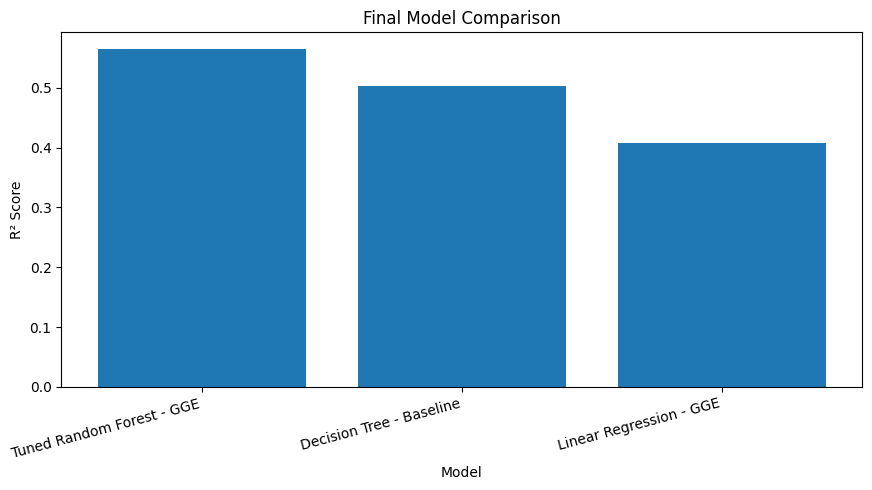

In [48]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["R2"]
)

plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Final Model Comparison")

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()
plt.show()

## Modeling Summary:
Three regression models were evaluated to predict fuel consumption in GGE: Random Forest, Decision Tree, and Linear Regression. The Random Forest model achieved the best overall performance after hyperparameter tuning, with an R² of 0.564 and an RMSE of approximately 1.86 million GGE. The Decision Tree achieved an R² of 0.502, while Linear Regression achieved an R² of 0.407. A log-transformed target was also tested, but it did not improve the overall Random Forest performance. Based on the comparison of the evaluation metrics, the Tuned Random Forest was selected as the final model. The results also indicate that the relationship between the available features and fuel consumption is complex and not fully explained by a simple linear model.